array([ 3.,  4.,  5.,  7.,  8., 10., 12., 15., 20., 25., 30., 40.])

 Optimization Complete:
 Best Fit Weight (w): 0.0459 (4.59%)
 Best Fit Sigma (σ):  4.57 cm


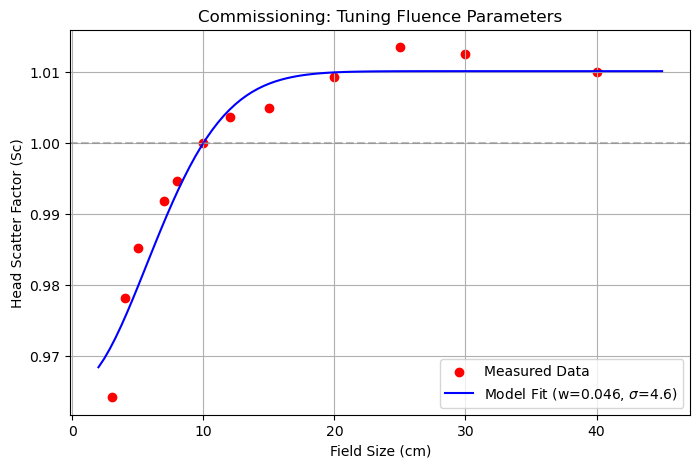

In [5]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erf
import matplotlib.pyplot as plt

# --- 1. THE DATA ---
# Field sizes (side of square in cm)
raw_data = np.array([[3,  0.9642], [4,  0.9782], [5,  0.9852], [7,  0.9918], [8,  0.9947], [10, 1.0000], [12, 1.0037], [15, 1.0049], [20, 1.0093], [25, 1.0135], [30, 1.0125], [40, 1.0100]])
field_sizes = raw_data[:, 0]
# Your Measured Sc (in-air output factors)
measured_sc = raw_data[:, 1]

# --- 2. THE PHYSICS MODEL ---
def sc_model(s, w, sigma):
    """
    s: Field Size (cm)
    w: Weight of scatter source (relative to primary)
    sigma: Width of scatter source (cm)
    """
    # Geometric Projection
    # Assume Source is at 50cm (Flattening Filter), Iso is at 100cm
    # Project field size 's' back to the source plane
    s_projected = s * (50.0 / 100.0) 
    
    # The 'View Factor' (Integral of Gaussian through square aperture)
    # Using erf because integral of exp(-x^2) is erf
    # We square it because it's a 2D square aperture (x * y)
    view_factor = (erf(s_projected / sigma))**2
    
    # Calculate Raw Intensity (Primary + Weighted Scatter)
    # Primary is 1.0 (constant point source)
    raw_intensity = 1.0 + (w * view_factor)
    
    # Normalize to 10x10 Field (Reference)
    ref_s_projected = 10.0 * (50.0 / 100.0)
    ref_view_factor = (erf(ref_s_projected / sigma))**2
    ref_intensity = 1.0 + (w * ref_view_factor)
    
    return raw_intensity / ref_intensity

# --- 3. THE OPTIMIZATION ALGORITHM ---
# We use Non-Linear Least Squares (curve_fit)
# Initial Guesses: w=0.05 (5%), sigma=5.0cm
p0 = [0.05, 5.0]

# Run the optimizer
popt, pcov = curve_fit(sc_model, field_sizes, measured_sc, p0=p0)

fitted_w, fitted_sigma = popt

# --- 4. RESULTS & VISUALIZATION ---
print(f" Optimization Complete:")
print(f" Best Fit Weight (w): {fitted_w:.4f} ({fitted_w*100:.2f}%)")
print(f" Best Fit Sigma (σ):  {fitted_sigma:.2f} cm")

# Generate smooth curve for plotting
s_smooth = np.linspace(2, 45, 100)
sc_smooth = sc_model(s_smooth, fitted_w, fitted_sigma)

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(field_sizes, measured_sc, color='red', label='Measured Data')
plt.plot(s_smooth, sc_smooth, color='blue', label=f'Model Fit (w={fitted_w:.3f}, $\sigma$={fitted_sigma:.1f})')
plt.axhline(1.0, linestyle='--', color='gray', alpha=0.5)
plt.xlabel('Field Size (cm)')
plt.ylabel('Head Scatter Factor (Sc)')
plt.title('Commissioning: Tuning Fluence Parameters')
plt.legend()
plt.grid(True)
plt.show()

 Optimization Complete:
 Best Fit Weight (w): 0.0571 (5.71%)
 Best Fit Sigma (σ):  4.95 cm


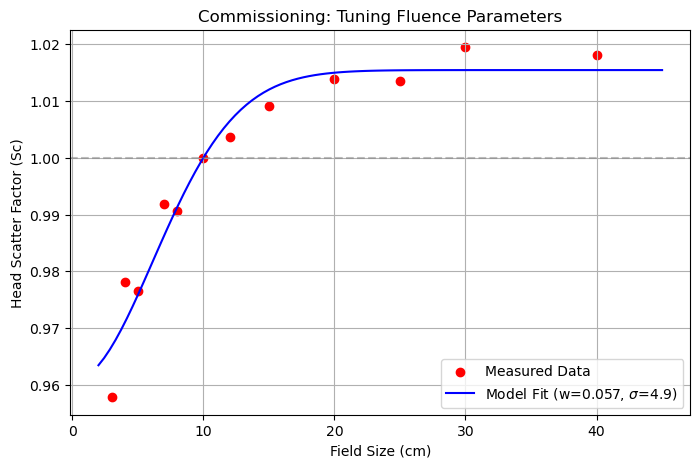

In [6]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import erf
import matplotlib.pyplot as plt

# --- 1. THE DATA ---
# Field sizes (side of square in cm)
raw_data = np.array([[3,  0.9578], [4,  0.9782], [5,  0.9766], [7,  0.9918], [8,  0.9907], [10, 1.0000], [12, 1.0037], [15, 1.0092], [20, 1.0139], [25, 1.0135], [30, 1.0195], [40, 1.0182]])
field_sizes = raw_data[:, 0]
# Your Measured Sc (in-air output factors)
measured_sc = raw_data[:, 1]

# --- 2. THE PHYSICS MODEL ---
def sc_model(s, w, sigma):
    """
    s: Field Size (cm)
    w: Weight of scatter source (relative to primary)
    sigma: Width of scatter source (cm)
    """
    # Geometric Projection
    # Assume Source is at 50cm (Flattening Filter), Iso is at 100cm
    # Project field size 's' back to the source plane
    s_projected = s * (50.0 / 100.0) 
    
    # The 'View Factor' (Integral of Gaussian through square aperture)
    # Using erf because integral of exp(-x^2) is erf
    # We square it because it's a 2D square aperture (x * y)
    view_factor = (erf(s_projected / sigma))**2
    
    # Calculate Raw Intensity (Primary + Weighted Scatter)
    # Primary is 1.0 (constant point source)
    raw_intensity = 1.0 + (w * view_factor)
    
    # Normalize to 10x10 Field (Reference)
    ref_s_projected = 10.0 * (50.0 / 100.0)
    ref_view_factor = (erf(ref_s_projected / sigma))**2
    ref_intensity = 1.0 + (w * ref_view_factor)
    
    return raw_intensity / ref_intensity

# --- 3. THE OPTIMIZATION ALGORITHM ---
# We use Non-Linear Least Squares (curve_fit)
# Initial Guesses: w=0.05 (5%), sigma=5.0cm
p0 = [0.05, 5.0]

# Run the optimizer
popt, pcov = curve_fit(sc_model, field_sizes, measured_sc, p0=p0)

fitted_w, fitted_sigma = popt

# --- 4. RESULTS & VISUALIZATION ---
print(f" Optimization Complete:")
print(f" Best Fit Weight (w): {fitted_w:.4f} ({fitted_w*100:.2f}%)")
print(f" Best Fit Sigma (σ):  {fitted_sigma:.2f} cm")

# Generate smooth curve for plotting
s_smooth = np.linspace(2, 45, 100)
sc_smooth = sc_model(s_smooth, fitted_w, fitted_sigma)

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(field_sizes, measured_sc, color='red', label='Measured Data')
plt.plot(s_smooth, sc_smooth, color='blue', label=f'Model Fit (w={fitted_w:.3f}, $\sigma$={fitted_sigma:.1f})')
plt.axhline(1.0, linestyle='--', color='gray', alpha=0.5)
plt.xlabel('Field Size (cm)')
plt.ylabel('Head Scatter Factor (Sc)')
plt.title('Commissioning: Tuning Fluence Parameters')
plt.legend()
plt.grid(True)
plt.show()